# Post-Fire Landslide Susceptibility Modeling — Nacimiento, Chile
### Variable 1: dNBR (Burn Severity)

**Author:** Constanza Morales Gajardo
**Part of:** Landslide Susceptibility Portfolio Project (P5)

## 1. Introduction

This notebook reprocesses the Normalized Burn Ratio (NBR) and differenced NBR (dNBR) for the February 2023 "Santa Ana" wildfire in Nacimiento, Biobío Region, Chile — as the first conditioning variable for a post-fire landslide susceptibility model.

- **Study area:** Nacimiento commune (GADM boundary, `NAME_3`)
- **Event:** "Santa Ana" megafire, February 2023
- **Data source:** Sentinel-2 Surface Reflectance (Copernicus/S2_SR_HARMONIZED)
- **Tools:** Google Earth Engine Python API, geemap, geopandas, rasterio

In [1]:
import ee
import geemap
import geopandas as gpd
import os

# Initialize Earth Engine
ee.Initialize(project='earth-engine-portfolio-498609')

print("Earth Engine initialized successfully")
print(f"geemap version: {geemap.__version__}")

Earth Engine initialized successfully
geemap version: 0.37.2


## 2. Study Area — Nacimiento Commune Boundary

Administrative boundary loaded from GADM level 3 (commune level), as FAO GAUL only reaches province level for Chile.

Nacimiento boundary loaded: 1 feature(s)


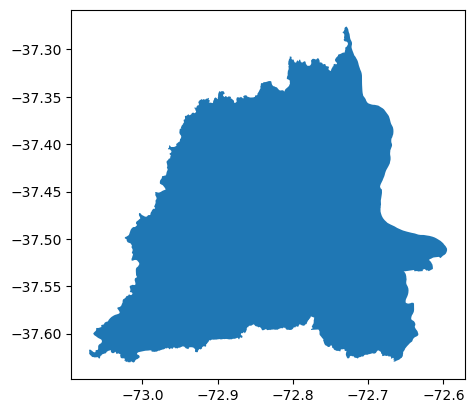

In [3]:
# Load Chile administrative boundaries (GADM level 3)
gadm_path = "../../nacimiento-wildfire-2023/data/raw/gadm41_CHL.gpkg"

# Adjust path if needed - check if file exists first
if not os.path.exists(gadm_path):
    print(f"File not found at: {gadm_path}")
    print("Please confirm the correct path to gadm41_CHL.gpkg")
else:
    chile_admin = gpd.read_file(gadm_path, layer='ADM_ADM_3')
    nacimiento = chile_admin[chile_admin['NAME_3'] == 'Nacimiento']
    print(f"Nacimiento boundary loaded: {len(nacimiento)} feature(s)")
    nacimiento.plot()

## 3. Sentinel-2 Image Collection — Pre and Post-Fire

Pre-fire and post-fire Sentinel-2 imagery dates, consistent with the wildfire severity analysis in the companion project (`nacimiento-wildfire-2023`).

- **Pre-fire date:** January 28, 2023
- **Post-fire date:** April 3, 2023

In [4]:
# Define pre-fire and post-fire date ranges
pre_fire_start = '2023-01-25'
pre_fire_end = '2023-01-31'

post_fire_start = '2023-03-31'
post_fire_end = '2023-04-06'

# Get the geometry from the Nacimiento boundary
aoi = geemap.geopandas_to_ee(nacimiento)

# Load Sentinel-2 Surface Reflectance collection, filtered and mosaicked
def get_s2_mosaic(start_date, end_date, aoi):
    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterBounds(aoi)
                  .filterDate(start_date, end_date)
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))
    return collection.mosaic().clip(aoi)

pre_fire_image = get_s2_mosaic(pre_fire_start, pre_fire_end, aoi)
post_fire_image = get_s2_mosaic(post_fire_start, post_fire_end, aoi)

print("Pre-fire and post-fire Sentinel-2 mosaics created")

Pre-fire and post-fire Sentinel-2 mosaics created


## 4. NBR and dNBR Calculation

The Normalized Burn Ratio (NBR) uses the Near-Infrared (NIR, B8) and Shortwave-Infrared (SWIR, B12) bands to highlight burned areas:

$$NBR = \frac{NIR - SWIR}{NIR + SWIR}$$

The differenced NBR (dNBR) quantifies burn severity by comparing pre-fire and post-fire NBR:

$$dNBR = NBR_{pre-fire} - NBR_{post-fire}$$

Higher dNBR values indicate greater burn severity.

In [5]:
def calculate_nbr(image):
    nir = image.select('B8')
    swir = image.select('B12')
    nbr = nir.subtract(swir).divide(nir.add(swir)).rename('NBR')
    return nbr

nbr_pre = calculate_nbr(pre_fire_image)
nbr_post = calculate_nbr(post_fire_image)

dnbr = nbr_pre.subtract(nbr_post).rename('dNBR')

print("NBR and dNBR calculated successfully")

NBR and dNBR calculated successfully


## 5. dNBR Visualization

Interactive map showing burn severity classes based on standard USGS dNBR thresholds.

In [6]:
# Visualization parameters for dNBR
dnbr_vis = {
    'min': -0.5,
    'max': 1.3,
    'palette': ['ffffff', 'ffff00', 'ff8000', 'ff0000', '800000']
}

Map = geemap.Map()
Map.centerObject(aoi, 11)
Map.addLayer(dnbr, dnbr_vis, 'dNBR')
Map.addLayer(aoi, {'color': 'black'}, 'Nacimiento boundary', False)
Map

Map(center=[-37.48548152276885, -72.82353068056327], controls=(WidgetControl(options=['position', 'transparent…

## 6. Export dNBR as Static GeoTIFF

Exporting dNBR as a static raster to `data/raw/` — this avoids dependency on temporary GEE tile tokens (which expire) and allows this layer to be used later as a static input variable in the weighted overlay model (Session 4).

In [7]:
# Export dNBR as GeoTIFF to data/raw/
output_path = '../data/raw/nacimiento_dnbr.tif'

geemap.ee_export_image(
    dnbr,
    filename=output_path,
    scale=20,
    region=aoi.geometry(),
    file_per_band=False
)

print(f"dNBR exported to: {output_path}")

Generating URL ...
Please wait ...
Data downloaded to C:\Users\const\Documents\gis_projects\nacimiento-landslide-susceptibility\data\raw\nacimiento_dnbr.tif
dNBR exported to: ../data/raw/nacimiento_dnbr.tif


## Conclusions

- dNBR successfully reprocessed for the Nacimiento study area, consistent with the "Santa Ana" wildfire severity analysis (February 2023).
- Output exported as a static GeoTIFF (`nacimiento_dnbr.tif`, 20m resolution) to `data/raw/`, ready to be used as the first conditioning variable in the landslide susceptibility weighted overlay model.
- **Next step (Session 2):** derive the slope variable from a DEM (SRTM/Copernicus) for the same study area.